# Demo of Spark GraphFrames

#### 1. Khởi tạo Spark Session với GraphFrames và Hive

In [15]:
!pip install networkx matplotlib

In [9]:
import warnings
import logging

# 1. Ẩn Python warnings
warnings.filterwarnings('ignore')

# 2. Ẩn PySpark log (nếu đang dùng Spark)
if 'spark' in globals():
    spark.sparkContext.setLogLevel("ERROR")
logging.getLogger("py4j").setLevel(logging.ERROR)


In [2]:
import os, sys
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, concat

spark = SparkSession.builder \
    .appName("Credit_Card_Fraud_Graph_Processing") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.2-spark3.2-s_2.12") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("hive.metastore.uris", "thrift://hive-metastore:9083") \
    .config("spark.sql.warehouse.dir", "hdfs://namenode:9000/user/hive/warehouse") \
    .enableHiveSupport() \
    .getOrCreate()



#### 2. Đọc dữ liệu Parquet từ Hive (hoặc HDFS)

In [3]:
# Đọc dữ liệu từ Hive table (giả sử bảng tên là 'credit_transactionscleaned_transactionscredit_transaction_db.cleaned_transactions')
# Hoặc đọc trực tiếp từ thư mục Parquet trên HDFS
spark.sql("USE credit_transaction_db")
df = spark.table("cleaned_transactions")

# Hiển thị Schema và số lượng dòng để kiểm tra
df.printSchema()
print(f"Tổng số giao dịch: {df.count():,}")

root
 |-- TRANSACTION_ID: long (nullable = true)
 |-- TX_DATETIME: timestamp (nullable = true)
 |-- CUSTOMER_ID: long (nullable = true)
 |-- TERMINAL_ID: long (nullable = true)
 |-- TX_AMOUNT: double (nullable = true)
 |-- TX_TIME_SECONDS: long (nullable = true)
 |-- TX_TIME_DAYS: integer (nullable = true)
 |-- TX_FRAUD: integer (nullable = true)
 |-- TX_FRAUD_SCENARIO: integer (nullable = true)
 |-- tx_date: date (nullable = true)
 |-- tx_hour: integer (nullable = true)
 |-- tx_day_of_week: string (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_night: integer (nullable = true)
 |-- customer_tx_count: long (nullable = true)
 |-- customer_avg_amount: double (nullable = true)
 |-- terminal_tx_count: long (nullable = true)
 |-- tx_year_month: string (nullable = true)

Tổng số giao dịch: 14,158,985


#### 3. Định nghĩa Bảng Đỉnh (Vertices)
Trong cấu trúc Đồ thị hai phía (Bipartite Graph), Vertex bắt buộc phải có cột tên là id. Ta sẽ tạo Đỉnh cho cả Khách hàng và Máy POS.

In [4]:
from pyspark.sql.functions import concat

# Thêm prefix C_ cho Khách hàng
customers = df.select(concat(lit("C_"), col("CUSTOMER_ID").cast("string")).alias("id")) \
              .distinct() \
              .withColumn("type", lit("Customer"))

# Thêm prefix T_ cho Terminal
terminals = df.select(concat(lit("T_"), col("TERMINAL_ID").cast("string")).alias("id")) \
              .distinct() \
              .withColumn("type", lit("Terminal"))

# Gộp lại thành bảng Vertices duy nhất
vertices = customers.union(terminals)

print(f"Tổng số đỉnh (Vertices): {vertices.count():,}")
vertices.show(5)

Tổng số đỉnh (Vertices): 109,997
+------+--------+
|    id|    type|
+------+--------+
|C_4756|Customer|
|C_3628|Customer|
|C_4672|Customer|
|C_2605|Customer|
|C_5013|Customer|
+------+--------+
only showing top 5 rows



#### 4. Định nghĩa Bảng Cạnh (Edges)

Cạnh đại diện cho giao dịch. Theo quy ước của GraphFrames, nguồn gửi phải là cột src và đích đến phải là cột dst. Luồng giao dịch sẽ đi từ CUSTOMER_ID -> TERMINAL_ID.

In [5]:
# Cập nhật ID nguồn và đích khớp với định dạng mới ở Vertices
edges = df.withColumn("src", concat(lit("C_"), col("CUSTOMER_ID").cast("string"))) \
          .withColumn("dst", concat(lit("T_"), col("TERMINAL_ID").cast("string")))

# Các cột còn lại (TX_DATETIME, TX_AMOUNT, TX_FRAUD...) tự động trở thành thuộc tính của Cạnh
print(f"Tổng số cạnh (Edges): {edges.count():,}")
edges.show(5)

Tổng số cạnh (Edges): 14,158,985
+--------------+-------------------+-----------+-----------+---------+---------------+------------+--------+-----------------+----------+-------+--------------+----------+--------+-----------------+-------------------+-----------------+-------------+------+-------+
|TRANSACTION_ID|        TX_DATETIME|CUSTOMER_ID|TERMINAL_ID|TX_AMOUNT|TX_TIME_SECONDS|TX_TIME_DAYS|TX_FRAUD|TX_FRAUD_SCENARIO|   tx_date|tx_hour|tx_day_of_week|is_weekend|is_night|customer_tx_count|customer_avg_amount|terminal_tx_count|tx_year_month|   src|    dst|
+--------------+-------------------+-----------+-----------+---------+---------------+------------+--------+-----------------+----------+-------+--------------+----------+--------+-----------------+-------------------+-----------------+-------------+------+-------+
|       6724753|2019-03-13 14:49:57|       9661|      99899|     4.28|       29947797|         346|       0|                0|2019-03-13|     14|           Wed|         

#### 5. Demo

##### 5.1. Demo 1: Thống kê cơ bản - Tìm các thiết bị POS có lượng giao dịch cao nhất

Kịch bản này dựa trên Fraud Scenario 2 (Thiết bị bị thỏa hiệp). Một thiết bị POS đột nhiên nhận quá nhiều giao dịch từ các khách hàng khác nhau có thể là dấu hiệu bất thường.  
- Ý tưởng: Tìm Top 10 Terminal có nhiều khách hàng thanh toán nhất.
- Phiên bản SQL/DataFrame: Sử dụng GROUP BY dst (hoặc TERMINAL_ID) và COUNT().
- Phiên bản GraphFrames: Sử dụng thuộc tính g.inDegrees.
- Mục tiêu so sánh:
    - Ưu điểm SQL: Chắc chắn SQL sẽ chạy nhanh hơn vì phép toán Group By được Spark tối ưu hóa cực tốt.
    - Nhược điểm GraphFrames: Phải tính toán trên cấu trúc topology nên sẽ có độ trễ (overhead).
    - Kết luận rút ra: Không phải lúc nào dùng Graph cũng tốt. Với các thống kê tập hợp (Aggregation) đơn thuần, hãy dùng SQL/DataFrame.

- Initiate graph for all of transactions

In [24]:
import time
from pyspark.sql.functions import col, desc
from graphframes import GraphFrame


# Khởi tạo Mạng lưới Đồ thị
g = GraphFrame(vertices, edges)

# Bật checkpoint directory (Bắt buộc với một số thuật toán đồ thị nặng)
spark.sparkContext.setCheckpointDir("hdfs://namenode:9000/user/spark/checkpoints")

print(f"Số lượng Cạnh (Sample): {edges.count():,}")
print(f"Số lượng Đỉnh (Sample): {vertices.count():,}")

Số lượng Cạnh (Sample): 14,158,985
Số lượng Đỉnh (Sample): 109,997


- By Spark SQL

In [25]:
import time
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, desc

# Khởi tạo dictionary để lưu thời gian chạy của tất cả các kịch bản
execution_times = {}

print("Đã khởi tạo biến lưu trữ thời gian execution_times.")

Đã khởi tạo biến lưu trữ thời gian execution_times.


In [26]:
print("--- DEMO 1: TÍNH IN-DEGREE BẰNG SPARK SQL/DATAFRAME ---")
print(f"Số lượng giao dịch (Cạnh) đang xử lý: {edges.count():,} \n")

start_sql = time.time()

# Gom nhóm theo thiết bị đích (dst) và đếm số lượng giao dịch
sql_indegree = edges.groupBy("dst").count().withColumnRenamed("count", "inDegree")

# Lấy Top 5 thiết bị
sql_result = sql_indegree.orderBy(desc("inDegree")).limit(5)

# Action: .show() kích hoạt xử lý và in kết quả ra màn hình
print("Top 5 Máy POS có lượng giao dịch đến cao nhất:")
sql_result.show() 

# Lưu thời gian
time_sql = time.time() - start_sql
execution_times['Demo 1 - Spark SQL'] = time_sql

print(f"-> Thời gian xử lý (Spark DataFrame): {time_sql:.4f} giây\n")

--- DEMO 1: TÍNH IN-DEGREE BẰNG SPARK SQL/DATAFRAME ---
Số lượng giao dịch (Cạnh) đang xử lý: 14,158,985 

Top 5 Máy POS có lượng giao dịch đến cao nhất:
+-------+--------+
|    dst|inDegree|
+-------+--------+
|T_11678|     254|
|T_74295|     251|
|T_55218|     249|
|T_42247|     248|
|T_43006|     246|
+-------+--------+

-> Thời gian xử lý (Spark DataFrame): 1.3624 giây



- By GraphFrames

In [27]:
print("--- DEMO 1: TÍNH IN-DEGREE BẰNG GRAPHFRAMES ---")

start_gf = time.time()

# Sử dụng thuộc tính inDegrees có sẵn của GraphFrames
gf_indegree = g.inDegrees

# Lấy Top 5 thiết bị
gf_result = gf_indegree.orderBy(desc("inDegree")).limit(5)

# Action: .show() kích hoạt xử lý và in kết quả ra màn hình
print("Top 5 Máy POS có lượng giao dịch đến cao nhất:")
gf_result.show()

# Lưu thời gian
time_gf = time.time() - start_gf
execution_times['Demo 1 - GraphFrames'] = time_gf

print(f"-> Thời gian xử lý (GraphFrames): {time_gf:.4f} giây\n")

--- DEMO 1: TÍNH IN-DEGREE BẰNG GRAPHFRAMES ---
Top 5 Máy POS có lượng giao dịch đến cao nhất:
+-------+--------+
|     id|inDegree|
+-------+--------+
|T_11678|     254|
|T_74295|     251|
|T_55218|     249|
|T_42247|     248|
|T_43006|     246|
+-------+--------+

-> Thời gian xử lý (GraphFrames): 23.7022 giây



- Visualize results

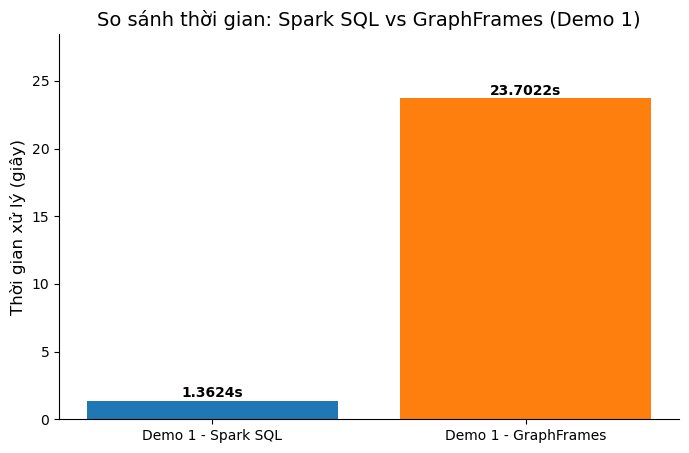

=> KẾT LUẬN: Với các phép tính toán thống kê (Aggregation) thuần túy trên quy mô lớn, Spark DataFrame/SQL là lựa chọn mặc định rất tốt và được tối ưu hóa sâu.


In [ ]:
# Trích xuất nhãn và dữ liệu thời gian
labels = list(execution_times.keys())
times = list(execution_times.values())

# Cấu hình biểu đồ
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, times, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Thời gian xử lý (giây)', fontsize=12)
plt.title('So sánh thời gian: Spark SQL vs GraphFrames (Demo 1)', fontsize=14)

# Thêm padding trục y để hiển thị text không bị lẹm
plt.ylim(0, max(times) * 1.2) 

# Gắn nhãn thời gian thực tế lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.4f}s', ha='center', va='bottom', fontweight='bold')

# Bỏ viền thừa cho biểu đồ thanh thoát
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()


##### 5.2. Demo 2: Khám phá mẫu hình (Motif Finding)

Trong phân tích gian lận, nếu khách hàng A giao dịch tại máy POS "X" (đã bị đánh dấu gian lận), thì khách hàng B giao dịch ngay sau đó tại POS "X" cũng có rủi ro bị lộ thông tin thẻ (Phishing).
- Mô tả kịch bản: Khách hàng gian lận (A) quẹt thẻ tại Máy POS (T1). Khách hàng bình thường (B) quẹt thẻ tại (T1) sau thời điểm của (A) nên bị lộ thông tin. Khách hàng (B) mang thẻ đi quẹt tiếp tại Máy POS (T2) sau đó. Yêu cầu tìm ra các máy POS (T2) đang có nguy cơ bị lây nhiễm.
- Mẫu hình (Pattern): A -> T1 <- B -> T2
- Phiên bản SQL/DataFrame: Phải thực hiện Self-Join bảng giao dịch (Edges) với chính nó thông qua dst (TERMINAL_ID) và điều kiện src khác nhau.
- Mục tiêu so sánh:
  - Cú pháp & Logic: Cú pháp của GraphFrames trực quan, dễ đọc, mang tư duy hình ảnh. Câu lệnh SQL Self-Join sẽ rất dài, dễ rối và tốn bộ nhớ.
  - Hiệu năng: Tùy thuộc vào chiến lược tối ưu, nhưng GraphFrames mang lại trải nghiệm viết code (Developer Experience) tốt hơn hẳn cho các pattern phức tạp (như Triangle, Path dài 3-4 bước).

- Khởi tạo dữ liệu mẫu, lấy dữ liệu tháng 04/2018, tạo thành g_sample và edges_sample.

In [ ]:
print("--- KHỞI TẠO DỮ LIỆU MẪU (1 THÁNG) CHO CÁC DEMO NÂNG CAO ---")

# Lấy mẫu dữ liệu của tháng 4/2018
edges_sample = edges.filter(col("tx_year_month") == "2018-04")

# Lọc Vertices tương ứng với tập Edges mẫu
sample_customers = edges_sample.select(col("src").alias("id")).distinct().withColumn("type", lit("Customer"))
sample_terminals = edges_sample.select(col("dst").alias("id")).distinct().withColumn("type", lit("Terminal"))
vertices_sample = sample_customers.union(sample_terminals)

# Khởi tạo GraphFrame mẫu
g_sample = GraphFrame(vertices_sample, edges_sample)

print(f"Số lượng Cạnh (Sample): {edges_sample.count():,}")
print(f"Số lượng Đỉnh (Sample): {vertices_sample.count():,}")

--- KHỞI TẠO DỮ LIỆU MẪU (1 THÁNG) CHO CÁC DEMO NÂNG CAO ---
Số lượng Cạnh (Sample): 582,506
Số lượng Đỉnh (Sample): 109,501


- Spark SQL

In [60]:
print("--- DEMO 2: TÌM MẪU HÌNH LÂY NHIỄM CHÉO BẰNG SPARK SQL (COMPLEX SELF-JOIN) ---")

start_sql2 = time.time()

# SQL phải Join 3 lần bảng edges_sample và xử lý logic cực kỳ cồng kềnh
sql_pattern = edges_sample.alias("e1") \
    .join(edges_sample.alias("e2"), col("e1.dst") == col("e2.dst")) \
    .join(edges_sample.alias("e3"), col("e2.src") == col("e3.src")) \
    .filter(
        (col("e1.src") != col("e2.src")) &                      # A khác B
        (col("e1.dst") != col("e3.dst")) &                      # T1 khác T2
        (col("e1.TX_FRAUD") == 1) &                             # Giao dịch 1 là gian lận
        (col("e2.TX_FRAUD") == 0) & (col("e3.TX_FRAUD") == 0) & # Giao dịch 2, 3 là bình thường
        (col("e2.TX_TIME_SECONDS") > col("e1.TX_TIME_SECONDS")) & # B quẹt sau A tại T1
        (col("e3.TX_TIME_SECONDS") > col("e2.TX_TIME_SECONDS"))   # B quẹt tại T2 sau khi quẹt tại T1
    )

# Chuẩn hóa cột hiển thị
sql_result2 = sql_pattern.select(
    col("e1.src").alias("Fraud_Customer_A"), 
    col("e1.dst").alias("Infected_POS_T1"), 
    col("e2.src").alias("Victim_Customer_B"),
    col("e3.dst").alias("At_Risk_POS_T2")
).dropDuplicates()

print(f"Tổng số chuỗi lây nhiễm tìm được bằng SQL: {sql_result2.count()}")
print("Kết quả 10 chuỗi lây nhiễm tìm được:")
# sql_result2.show()
sql_result2.orderBy("Fraud_Customer_A", "Infected_POS_T1", "Victim_Customer_B","At_Risk_POS_T2").show(10, truncate=False)

# Lưu thời gian
time_sql2 = time.time() - start_sql2
execution_times['Demo 2 - Spark SQL'] = time_sql2

print(f"-> Thời gian xử lý (Spark SQL): {time_sql2:.4f} giây\n")

--- DEMO 2: TÌM MẪU HÌNH LÂY NHIỄM CHÉO BẰNG SPARK SQL (COMPLEX SELF-JOIN) ---
Tổng số chuỗi lây nhiễm tìm được bằng SQL: 52044
Kết quả 10 chuỗi lây nhiễm tìm được:
+----------------+---------------+-----------------+--------------+
|Fraud_Customer_A|Infected_POS_T1|Victim_Customer_B|At_Risk_POS_T2|
+----------------+---------------+-----------------+--------------+
|C_1051          |T_28176        |C_7254           |T_12431       |
|C_1051          |T_28176        |C_7254           |T_1438        |
|C_1051          |T_28176        |C_7254           |T_16339       |
|C_1051          |T_28176        |C_7254           |T_22967       |
|C_1051          |T_28176        |C_7254           |T_32199       |
|C_1051          |T_28176        |C_7254           |T_33403       |
|C_1051          |T_28176        |C_7254           |T_36640       |
|C_1051          |T_28176        |C_7254           |T_40890       |
|C_1051          |T_28176        |C_7254           |T_44915       |
|C_1051          |T

- GraphFrames

In [61]:
print("--- DEMO 2: TÌM MẪU HÌNH LÂY NHIỄM CHÉO BẰNG GRAPHFRAMES (MOTIF FINDING) ---")

start_gf2 = time.time()

# Cú pháp Motif trực quan mô phỏng chuỗi: A tới T1, B tới T1, B tới T2
motifs = g_sample.find("(a)-[e1]->(t1); (b)-[e2]->(t1); (b)-[e3]->(t2)")

# Lọc điều kiện trên Motif một cách gãy gọn
gf_pattern = motifs.filter("""
    a.id != b.id AND t1.id != t2.id AND 
    e1.TX_FRAUD = 1 AND e2.TX_FRAUD = 0 AND e3.TX_FRAUD = 0 AND 
    e2.TX_TIME_SECONDS > e1.TX_TIME_SECONDS AND 
    e3.TX_TIME_SECONDS > e2.TX_TIME_SECONDS
""")

# Chuẩn hóa cột hiển thị giống hệt SQL
gf_result2 = gf_pattern.select(
    col("a.id").alias("Fraud_Customer_A"), 
    col("t1.id").alias("Infected_POS_T1"), 
    col("b.id").alias("Victim_Customer_B"),
    col("t2.id").alias("At_Risk_POS_T2")
).dropDuplicates()

print(f"Tổng số chuỗi lây nhiễm tìm được bằng GraphFrames: {gf_result2.count()}")
print("Kết quả 10 chuỗi lây nhiễm tìm được:")
# gf_result2.show()
gf_result2.orderBy("Fraud_Customer_A", "Infected_POS_T1", "Victim_Customer_B","At_Risk_POS_T2").show(10, truncate=False)

# Lưu thời gian
time_gf2 = time.time() - start_gf2
execution_times['Demo 2 - GraphFrames'] = time_gf2

print(f"-> Thời gian xử lý (GraphFrames Motif Finding): {time_gf2:.4f} giây\n")

--- DEMO 2: TÌM MẪU HÌNH LÂY NHIỄM CHÉO BẰNG GRAPHFRAMES (MOTIF FINDING) ---
Tổng số chuỗi lây nhiễm tìm được bằng GraphFrames: 52044
Kết quả 10 chuỗi lây nhiễm tìm được:
+----------------+---------------+-----------------+--------------+
|Fraud_Customer_A|Infected_POS_T1|Victim_Customer_B|At_Risk_POS_T2|
+----------------+---------------+-----------------+--------------+
|C_1051          |T_28176        |C_7254           |T_12431       |
|C_1051          |T_28176        |C_7254           |T_1438        |
|C_1051          |T_28176        |C_7254           |T_16339       |
|C_1051          |T_28176        |C_7254           |T_22967       |
|C_1051          |T_28176        |C_7254           |T_32199       |
|C_1051          |T_28176        |C_7254           |T_33403       |
|C_1051          |T_28176        |C_7254           |T_36640       |
|C_1051          |T_28176        |C_7254           |T_40890       |
|C_1051          |T_28176        |C_7254           |T_44915       |
|C_1051      

##### 5.3. Demo 3: Tìm đường đi ngắn nhất (Breadth-First Search - BFS) - Dấu vết dòng rủi ro

Giả sử bạn bắt được một khách hàng lừa đảo (Customer rủi ro), bạn muốn tìm xem khách hàng này cách một khách hàng VIP bao nhiêu bước (qua các máy POS dùng chung).
- Ý tưởng: Tìm đường đi ngắn nhất (chênh lệch dưới 3 hops) từ Khách hàng gian lận đến các Khách hàng bình thường để cảnh báo khóa thẻ.
- Phiên bản SQL/DataFrame: Spark SQL thuần gần như không thể/rất khó làm được bài toán tìm đường đi độ sâu biến thiên (variable-depth) mà không dùng Recursive CTE hoặc vòng lặp For trong Python để Join liên tục.
- Phiên bản GraphFrames: Sử dụng hàm g.bfs(fromExpr="id = 'C_123'", toExpr="type = 'Customer'", maxPathLength=3).
- Mục tiêu so sánh: Nhấn mạnh rằng GraphFrames giải quyết được những bài toán mà Dữ liệu bảng (Relational/Tabular Data) chịu trói hoặc phải dùng thuật toán cực kỳ tốn tài nguyên.

- Spark SQL/DataFrame (Mô phỏng thuật toán BFS)

In [62]:
print("--- DEMO 3: TRUY VẾT LÂY NHIỄM BẰNG SPARK DATAFRAME (MÔ PHỎNG BREADTH-FIRST SEARCH) ---")
print("Spark SQL không hỗ trợ Native BFS. Chúng ta phải sử dụng kỹ thuật Iterative Joins (Join liên tục) để mô phỏng.\n")

start_sql3 = time.time()

# Khách hàng nguồn cần truy vết (Khách hàng gian lận)
source_customer = 'C_1051'

# -------------------------------------------------------------------------
# Bước 1 (Hop 1 & 2): Khách hàng gian lận (v0) -> Máy POS (v1) -> Khách hàng lây nhiễm cấp 1 (v2)
# -------------------------------------------------------------------------
hop_1_2 = edges_sample.alias("e1").filter(col("e1.src") == source_customer) \
    .join(edges_sample.alias("e2"), col("e1.dst") == col("e2.dst")) \
    .filter(col("e1.src") != col("e2.src")) \
    .select(
        col("e1.src").alias("v0"), 
        col("e1.dst").alias("v1"), 
        col("e2.src").alias("v2")
    ).dropDuplicates()

# -------------------------------------------------------------------------
# Bước 2 (Hop 3 & 4): Khách hàng lây nhiễm cấp 1 (v2) -> Máy POS mới (v3) -> Khách hàng lây nhiễm cấp 2 (v4)
# -------------------------------------------------------------------------
# Lưu ý: Cần thêm các điều kiện để tránh các chu trình lặp (Cycle) quay lại các node cũ
hop_3_4 = hop_1_2.alias("h") \
    .join(edges_sample.alias("e3"), col("h.v2") == col("e3.src")) \
    .filter(col("h.v1") != col("e3.dst")) \
    .join(edges_sample.alias("e4"), col("e3.dst") == col("e4.dst")) \
    .filter(
        (col("e4.src") != col("h.v2")) &  # Không quay lại Khách hàng cấp 1
        (col("e4.src") != col("h.v0"))    # Không quay lại Khách hàng gốc
    ) \
    .select(
        col("h.v0").alias("Source_Customer"),
        col("h.v1").alias("POS_Hop_1"),
        col("h.v2").alias("Customer_Hop_2"),
        col("e3.dst").alias("POS_Hop_3"),
        col("e4.src").alias("Customer_Hop_4")
    ).dropDuplicates()

# Action: Kích hoạt chuỗi Join 
count_paths_sql = hop_3_4.count()
time_sql3 = time.time() - start_sql3
execution_times['Demo 3 - Spark SQL (Simulated BFS)'] = time_sql3

print(f"Đã tìm thấy {count_paths_sql} đường đi lây nhiễm (4 hops).")
if count_paths_sql > 0:
    hop_3_4.show(5, truncate=False)

print(f"-> Thời gian xử lý (Spark SQL - Iterative Joins): {time_sql3:.4f} giây\n")

--- DEMO 3: TRUY VẾT LÂY NHIỄM BẰNG SPARK DATAFRAME (MÔ PHỎNG BREADTH-FIRST SEARCH) ---
Spark SQL không hỗ trợ Native BFS. Chúng ta phải sử dụng kỹ thuật Iterative Joins (Join liên tục) để mô phỏng.

Đã tìm thấy 113073 đường đi lây nhiễm (4 hops).
+---------------+---------+--------------+---------+--------------+
|Source_Customer|POS_Hop_1|Customer_Hop_2|POS_Hop_3|Customer_Hop_4|
+---------------+---------+--------------+---------+--------------+
|C_1051         |T_89308  |C_5081        |T_84068  |C_5712        |
|C_1051         |T_89308  |C_5081        |T_84068  |C_4034        |
|C_1051         |T_89308  |C_5081        |T_84068  |C_5642        |
|C_1051         |T_89308  |C_5081        |T_84068  |C_1004        |
|C_1051         |T_89308  |C_5081        |T_78593  |C_5380        |
+---------------+---------+--------------+---------+--------------+
only showing top 5 rows

-> Thời gian xử lý (Spark SQL - Iterative Joins): 0.7963 giây



- GraphFrames

In [63]:
print("2. Đang chạy bằng GraphFrames (Breadth-First Search)...")
start_gf3 = time.time()

# Giả sử ta phát hiện 'C_1051' (từ kết quả Demo 2) là thẻ tín dụng gian lận. 
maxPathLength = 4
# Ta muốn tìm đường đi lây nhiễm (ngắn nhất) đến các khách hàng khác (khoảng cách tối đa 4 hops).
paths = g_sample.bfs(
    fromExpr="id = 'C_1051'",               # Điểm xuất phát: Khách hàng C_1051
    toExpr="type = 'Customer' AND id != 'C_1051'", # Điểm đích: Một khách hàng khác
    maxPathLength=maxPathLength                         # Số bước tối đa
)

# Lấy 5 kết quả đầu tiên (Loại bỏ trùng lặp nếu có)
gf_result3 = paths.dropDuplicates()

# Action
count_paths = gf_result3.count()
time_gf3 = time.time() - start_gf3

print(f"Đã tìm thấy {count_paths} đường lây nhiễm chéo.")
if count_paths > 0:
    print("Danh sách các đường đi lây nhiễm (Ngắn nhất):")
    # Tùy thuộc vào cấu trúc trả về của BFS (v0, e0, v1, e1,...), ta hiển thị giới hạn để dễ nhìn
    gf_result3.show(5, truncate=False)
else:
    print(f"Không tìm thấy đường đi chung POS nào cho khách hàng này trong tập mẫu với maxPathLength={maxPathLength:d}.")

# Lưu thời gian
execution_times['Demo 3 - GraphFrames (BFS)'] = time_gf3

print(f"-> Thời gian xử lý (GraphFrames BFS): {time_gf3:.4f} giây\n")

2. Đang chạy bằng GraphFrames (Breadth-First Search)...
Đã tìm thấy 0 đường lây nhiễm chéo.
Không tìm thấy đường đi chung POS nào cho khách hàng này trong tập mẫu với maxPathLength=4.
-> Thời gian xử lý (GraphFrames BFS): 5.5991 giây



In [69]:
print("2. Đang chạy bằng GraphFrames (Breadth-First Search)...")
start_gf3 = time.time()

# 1. Tạo tập cạnh đảo ngược để giải quyết vấn đề đồ thị có hướng (Bidirectional Graph)
reverse_edges = edges_sample.select(
    col("dst").alias("src"), 
    col("src").alias("dst"),
    "TX_AMOUNT", "TX_DATETIME", "TX_TIME_SECONDS", "TX_FRAUD"
)

# 2. Gộp cạnh gốc và cạnh đảo chiều
bidirectional_edges = edges_sample.select("src", "dst", "TX_AMOUNT", "TX_DATETIME", "TX_TIME_SECONDS", "TX_FRAUD") \
    .unionByName(reverse_edges)

# 3. Khởi tạo lại Graph với cạnh 2 chiều
g_bidirectional = GraphFrame(vertices_sample, bidirectional_edges)

# 4. Chạy BFS (Tìm đường lây nhiễm chéo tối đa 4 hops)
paths = g_bidirectional.bfs(
    fromExpr="id = 'C_1051'",               
    toExpr="type = 'Customer' AND id != 'C_1051'", 
    maxPathLength=4                         
)

# 5. CHUẨN HÓA CỘT HIỂN THỊ ĐỂ GIỐNG HỆT SPARK SQL
available_cols = paths.columns

select_exprs = [col("from.id").alias("Source_Customer")]
if "v1" in available_cols:
    select_exprs.append(col("v1.id").alias("POS_Hop_1"))
if "v2" in available_cols:
    select_exprs.append(col("v2.id").alias("Customer_Hop_2"))
if "v3" in available_cols:
    select_exprs.append(col("v3.id").alias("POS_Hop_3"))
if "to" in available_cols:
    select_exprs.append(col("to.id").alias("Customer_Hop_4"))

gf_result3_formatted = paths.select(*select_exprs).dropDuplicates()

# Action
count_paths = gf_result3_formatted.count()
time_gf3 = time.time() - start_gf3

print(f"Đã tìm thấy {count_paths} đường lây nhiễm chéo (4 hops).")
if count_paths > 0:
    print("Danh sách các đường đi lây nhiễm (Ngắn nhất):")
    gf_result3_formatted.show(5, truncate=False)
else:
    print("Không tìm thấy đường đi chung POS nào cho khách hàng này trong tập mẫu với maxPathLength=4.")

# Lưu thời gian
execution_times['Demo 3 - GraphFrames (BFS)'] = time_gf3

print(f"-> Thời gian xử lý (GraphFrames BFS): {time_gf3:.4f} giây\n")

2. Đang chạy bằng GraphFrames (Breadth-First Search)...
Đã tìm thấy 289 đường lây nhiễm chéo (4 hops).
Danh sách các đường đi lây nhiễm (Ngắn nhất):
+---------------+---------+--------------+
|Source_Customer|POS_Hop_1|Customer_Hop_4|
+---------------+---------+--------------+
|C_1051         |T_53436  |C_5774        |
|C_1051         |T_53436  |C_8924        |
|C_1051         |T_53436  |C_7548        |
|C_1051         |T_53436  |C_2462        |
|C_1051         |T_53436  |C_2153        |
+---------------+---------+--------------+
only showing top 5 rows

-> Thời gian xử lý (GraphFrames BFS): 3.0904 giây



##### 5.4. Demo 4: Phân tích cộng đồng (PageRank / Label Propagation)

Gian lận có tổ chức (Fraud Scenario 3) thường tạo thành các cụm (clusters).
- Ý tưởng: Sử dụng thuật toán Lan truyền nhãn (Label Propagation - LPA) để phân nhóm các cộng đồng thẻ tín dụng thường xuyên giao dịch chung tại các cụm máy POS nhất định.
- Phiên bản SQL/DataFrame: Bỏ qua, vì SQL không hỗ trợ thuật toán Machine Learning/Graph Analytics mạng lưới.
- Phiên bản GraphFrames: Chạy g.labelPropagation(maxIter=5).
- Mục tiêu so sánh: Thể hiện khả năng kết hợp các thuật toán đồ thị phức tạp (đã được xây dựng sẵn) của GraphFrames để cung cấp các features mới (Graph features) cho mô hình dự đoán Machine Learning.

In [71]:
print("--- DEMO 4: GRAPH ANALYTICS - LABEL PROPAGATION ALGORITHM (LPA) ---")
# Phiên bản SQL: KHÔNG THỂ THỰC HIỆN ĐƯỢC

print("Bắt đầu chạy LPA (Sẽ mất vài chục giây đến vài phút tùy cấu hình cluster)...")
start_lpa = time.time()

# maxIter=3 để demo chạy nhanh. Trong thực tế có thể đặt 5-10
result_lpa = g_sample.labelPropagation(maxIter=3)

# Đếm số lượng cộng đồng (Mỗi cộng đồng được gán 1 label duy nhất)
num_communities = result_lpa.select("label").distinct().count()

print(f"Thời gian chạy LPA: {time.time() - start_lpa:.4f} giây")
print(f"Đã phân nhóm đồ thị thành {num_communities} cộng đồng độc lập.")

# Hiển thị thử 5 Node thuộc cùng 1 cụm cộng đồng ngẫu nhiên
sample_label = result_lpa.select("label").first()[0]
result_lpa.filter(col("label") == sample_label).show(5)

--- DEMO 4: GRAPH ANALYTICS - LABEL PROPAGATION ALGORITHM (LPA) ---
Bắt đầu chạy LPA (Sẽ mất vài chục giây đến vài phút tùy cấu hình cluster)...
Thời gian chạy LPA: 332.0709 giây
Đã phân nhóm đồ thị thành 12683 cộng đồng độc lập.
+------+--------+-----+
|    id|    type|label|
+------+--------+-----+
|C_3465|Customer|46369|
|C_4299|Customer|46369|
|C_6099|Customer|46369|
|C_2110|Customer|46369|
|C_6014|Customer|46369|
+------+--------+-----+
only showing top 5 rows



##### 5.5. Visualize Results

- Processed time between Spark SQL and GraphFrames

--- TỔNG KẾT: SO SÁNH HIỆU NĂNG XỬ LÝ ---


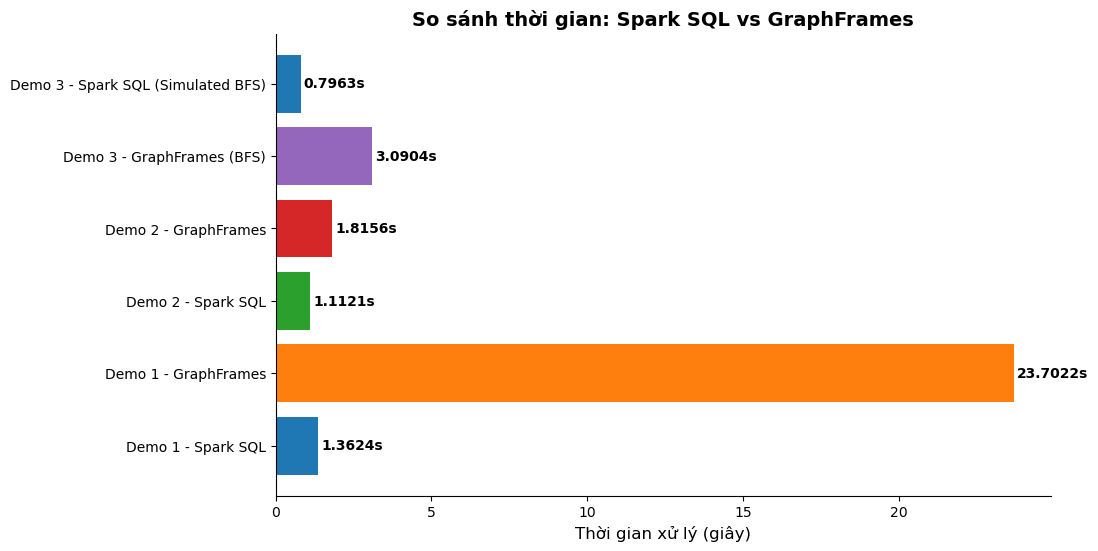

In [73]:
import matplotlib.pyplot as plt

print("--- TỔNG KẾT: SO SÁNH HIỆU NĂNG XỬ LÝ ---")

# Lấy dữ liệu từ dictionary execution_times
labels = list(execution_times.keys())
times = list(execution_times.values())

# Vẽ biểu đồ thanh ngang
plt.figure(figsize=(10, 6))
bars = plt.barh(labels, times, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:len(labels)])
plt.xlabel('Thời gian xử lý (giây)', fontsize=12)
plt.title('So sánh thời gian: Spark SQL vs GraphFrames', fontsize=14, fontweight='bold')

# Thêm text thời gian thực tế bên cạnh mỗi cột
for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 0.1, bar.get_y() + bar.get_height()/2, f'{xval:.4f}s', va='center', fontweight='bold')

# Căn chỉnh lại viền biểu đồ cho thanh thoát
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

- Trực quan hóa Chuỗi lây nhiễm chéo (Dành cho Demo 2 hoặc Demo 3)

--- TRỰC QUAN HÓA CHUỖI LÂY NHIỄM (FRAUD RINGS) ---


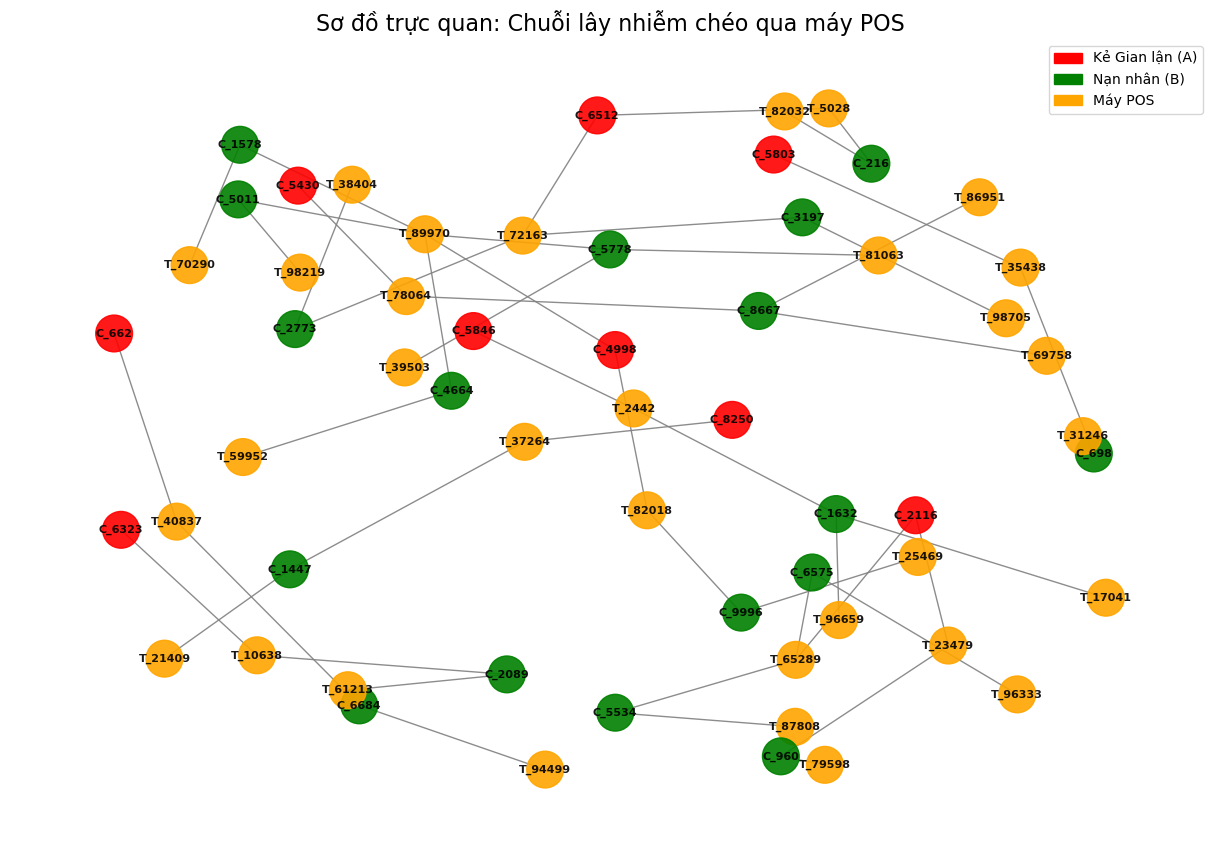

In [74]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("--- TRỰC QUAN HÓA CHUỖI LÂY NHIỄM (FRAUD RINGS) ---")

# Chuyển đổi khoảng 20 chuỗi từ kết quả GraphFrames sang Pandas DataFrame
sample_patterns_pd = gf_result2.limit(20).toPandas()

# Khởi tạo đồ thị NetworkX
G = nx.Graph()

# Duyệt qua các dòng và thêm Node/Edge
for _, row in sample_patterns_pd.iterrows():
    fraud_node = row['Fraud_Customer_A']
    terminal_1 = row['Infected_POS_T1']
    victim_node = row['Victim_Customer_B']
    terminal_2 = row['At_Risk_POS_T2']
    
    # Thêm Node với thuộc tính màu sắc để phân biệt
    G.add_node(fraud_node, color='red')          # Kẻ gian lận
    G.add_node(terminal_1, color='orange')       # POS bị nhiễm
    G.add_node(victim_node, color='green')       # Nạn nhân
    G.add_node(terminal_2, color='orange')       # POS rủi ro
    
    # Thêm các cạnh nối (Giao dịch)
    G.add_edge(fraud_node, terminal_1)
    G.add_edge(victim_node, terminal_1)
    G.add_edge(victim_node, terminal_2)

# Lấy mảng màu sắc cho các node đã add
color_map = [nx.get_node_attributes(G, 'color').get(node, 'gray') for node in G.nodes()]

# Thiết lập và vẽ đồ thị
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.6) # Thuật toán dàn trang Spring Layout
nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=700, font_size=8, font_weight="bold", edge_color="gray", alpha=0.9)

# Tạo chú thích (Legend)
red_patch = mpatches.Patch(color='red', label='Kẻ Gian lận (A)')
green_patch = mpatches.Patch(color='green', label='Nạn nhân (B)')
orange_patch = mpatches.Patch(color='orange', label='Máy POS')
plt.legend(handles=[red_patch, green_patch, orange_patch], loc='upper right')

plt.title("Sơ đồ trực quan: Chuỗi lây nhiễm chéo qua máy POS", fontsize=16)
plt.show()

- Trực quan hóa Cộng đồng (Dành cho Demo 4 - LPA)

--- TRỰC QUAN HÓA CỘNG ĐỒNG (TÍCH HỢP ĐÁNH DẤU RỦI RO GIAN LẠN) ---
📌 Cộng đồng [5242]: 33 Khách hàng, 20 Máy POS | ⚠️ Có 3 Khách hàng gian lận


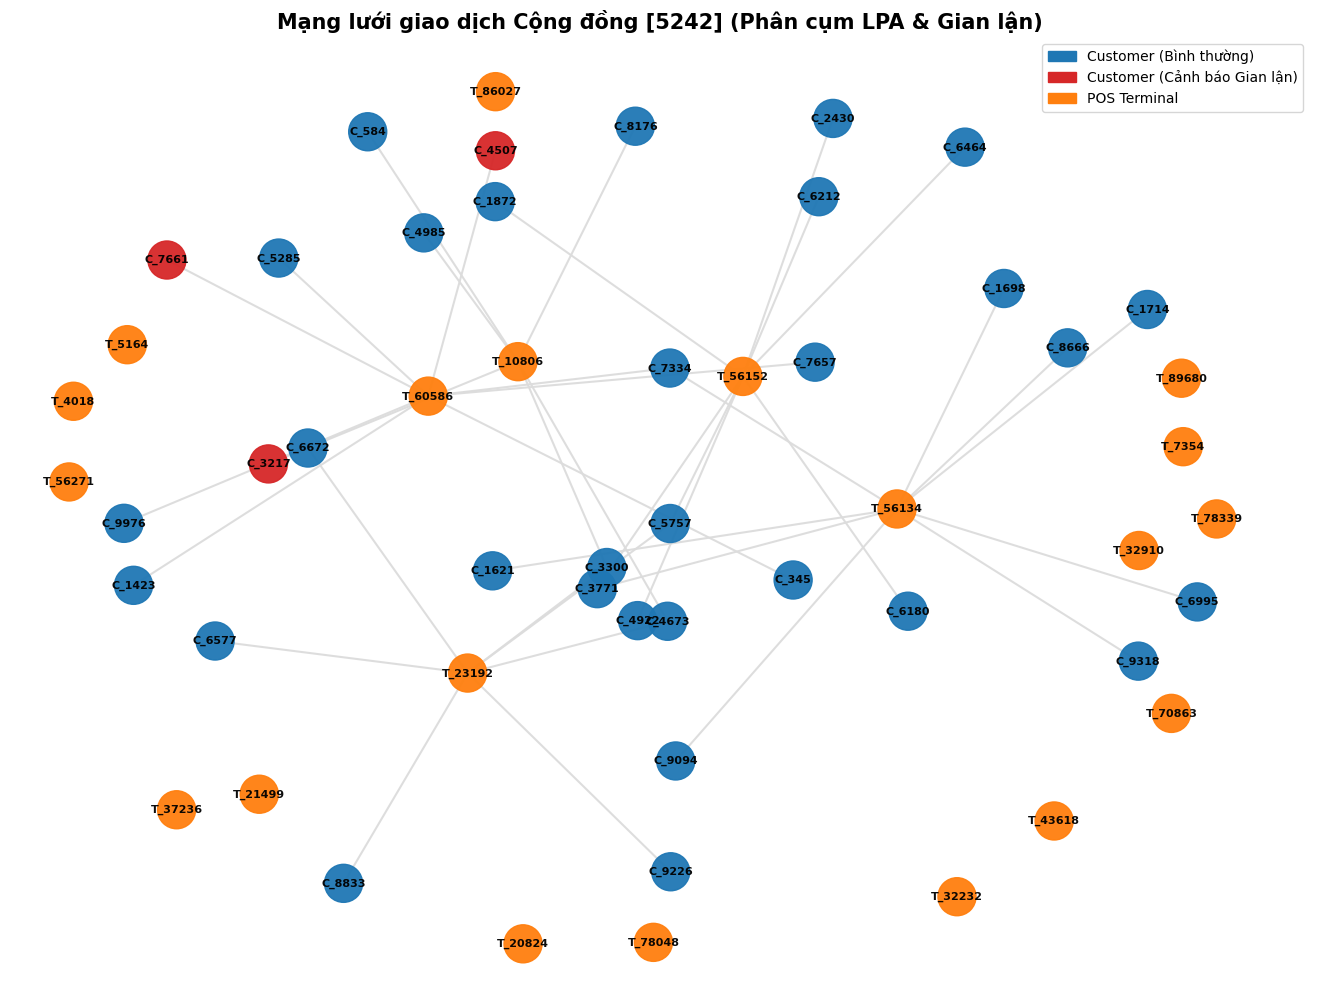

In [88]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pyspark.sql.functions import col, desc, max as spark_max

print("--- TRỰC QUAN HÓA CỘNG ĐỒNG (TÍCH HỢP ĐÁNH DẤU RỦI RO GIAN LẠN) ---")

if 'result_lpa' in globals():
    # 1. Tìm nhãn cộng đồng có nhiều thành viên nhất
    top_community_row = result_lpa.groupBy("label").count().orderBy(desc("count")).limit(1).collect()
    
    if top_community_row:
        top_label = top_community_row[0]["label"]
        
        # 2. Trích xuất nút Customer & Terminal thuộc cụm
        nodes_in_community = result_lpa.filter(col("label") == top_label)
        cust_nodes = nodes_in_community.filter(col("type") == "Customer").limit(20)
        term_nodes = nodes_in_community.filter(col("type") == "Terminal").limit(20)
        
        community_nodes_pd = cust_nodes.union(term_nodes).toPandas()
        node_ids = community_nodes_pd['id'].tolist()

        # 3. Lọc cạnh giao dịch nội bộ
        community_edges_pd = edges_sample.filter(
            col("src").isin(node_ids) & col("dst").isin(node_ids)
        ).toPandas()
        
        if community_edges_pd.empty:
            community_edges_pd = edges_sample.filter(
                col("src").isin(node_ids) | col("dst").isin(node_ids)
            ).limit(40).toPandas()
            
            extra_src = community_edges_pd['src'].tolist()
            extra_dst = community_edges_pd['dst'].tolist()
            all_node_ids = list(set(node_ids + extra_src + extra_dst))
            community_nodes_pd = result_lpa.filter(col("id").isin(all_node_ids)).toPandas()

        # 4. Kiểm tra thông tin Gian lận từ edges_sample
        fraud_customers = edges_sample.filter(col("TX_FRAUD") == 1).select("src").distinct().toPandas()['src'].tolist()

        # In thống kê nhanh về cụm
        num_cust = len(community_nodes_pd[community_nodes_pd['type'] == 'Customer'])
        num_term = len(community_nodes_pd[community_nodes_pd['type'] == 'Terminal'])
        num_fraud_cust = len([cid for cid in community_nodes_pd['id'] if cid in fraud_customers])

        print(f"📌 Cộng đồng [{top_label}]: {num_cust} Khách hàng, {num_term} Máy POS | ⚠️ Có {num_fraud_cust} Khách hàng gian lận")

        # 5. Xây dựng đồ thị NetworkX
        G_comm = nx.Graph()
        color_map_comm = []
        
        for _, row in community_nodes_pd.iterrows():
            nid = row['id']
            if row['type'] == 'Customer':
                if nid in fraud_customers:
                    color = '#d62728' # Màu đỏ: Khách hàng Gian lận
                else:
                    color = '#1f77b4' # Màu xanh: Khách hàng Bình thường
            else:
                color = '#ff7f0e'     # Màu cam: POS Terminal
                
            G_comm.add_node(nid, color=color)

        for _, row in community_edges_pd.iterrows():
            G_comm.add_edge(row['src'], row['dst'])

        color_map_comm = [nx.get_node_attributes(G_comm, 'color').get(node, 'gray') for node in G_comm.nodes()]

        # 6. Vẽ biểu đồ đồ thị
        plt.figure(figsize=(13, 9.5))
        pos_comm = nx.spring_layout(G_comm, k=0.65, seed=42)
        
        nx.draw(
            G_comm, 
            pos_comm, 
            with_labels=True, 
            node_color=color_map_comm, 
            node_size=750, 
            font_size=8, 
            font_weight='bold',
            edge_color="gainsboro",
            width=1.5,
            alpha=0.95
        )
        
        # Legend chú thích 3 nhóm rõ ràng
        blue_patch = mpatches.Patch(color='#1f77b4', label='Customer (Bình thường)')
        red_patch = mpatches.Patch(color='#d62728', label='Customer (Cảnh báo Gian lận)')
        orange_patch = mpatches.Patch(color='#ff7f0e', label='POS Terminal')
        
        plt.legend(handles=[blue_patch, red_patch, orange_patch], loc='upper right', fontsize=10, frameon=True)
        plt.title(f"Mạng lưới giao dịch Cộng đồng [{top_label}] (Phân cụm LPA & Gian lận)", fontsize=15, fontweight='bold')
        plt.show()
    else:
        print("Không tìm thấy nhãn cộng đồng.")
